In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

## PLOTS OF IG

In [3]:
def compute_IGs(imbalances, correction=True):    
    n_indep_realizations = imbalances.shape[0]
    n_taus = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_taus),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_taus),alphas_max] / np.sqrt(n_indep_realizations)

    if correction:
        IGs[imbalances[:,:,0].mean(axis=0) > 1] = 0
        errors[imbalances[:,:,0].mean(axis=0) > 1] = 0
        
    return IGs, errors

### k = 5

In [6]:
k = 5

seeds = np.arange(1,15)
cases = [0,1,2]
taus = np.linspace(0,100,21,dtype=int)
alphas = np.linspace(0,1,300)

imbs_XtoY = {}
imbs_YtoX = {}

for case in cases:
    imbs_XtoY[case] = np.zeros((len(seeds),len(taus),len(alphas)))
    imbs_YtoX[case] = np.zeros((len(seeds),len(taus),len(alphas)))
    for iseed, seed in enumerate(seeds):
        with open(f"/scratch/vdeltatt/imbalance-gain-causality/tests_for_debarshi/ene_vs_tor/pickles_ig/seed{seed}_case{case}_k{k}.p","rb") as f:
            taus, alphas, imbs_XtoY[case][iseed], imbs_YtoX[case][iseed] = pickle.load(f)

IGs_XtoY = {}
IGs_YtoX = {}
errs_XtoY = {}
errs_YtoX = {}
for case in cases:
    IGs_XtoY[case], errs_XtoY[case] = compute_IGs(imbs_XtoY[case], correction=True)
    IGs_YtoX[case], errs_YtoX[case] = compute_IGs(imbs_YtoX[case], correction=True)

In [7]:
dict_targets = {0: "IP(SR) + IP(LR)", 1: "IW(SR) + IW(LR)", 2: "II(SR) + II(LR)"}

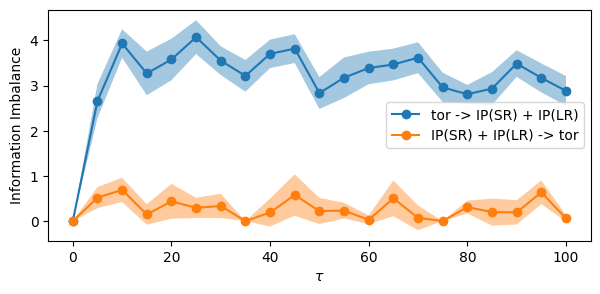

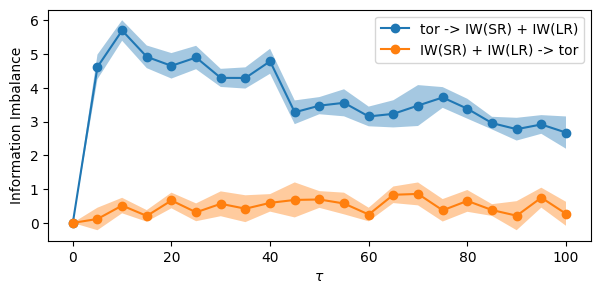

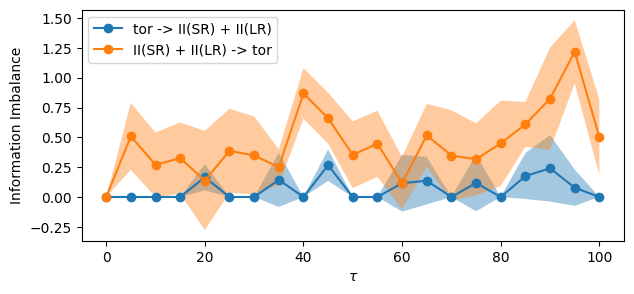

In [9]:
for case in cases:
    plt.figure(figsize=(7,3))
    plt.plot(taus, IGs_XtoY[case], 'o-', label=f"tor -> {dict_targets[case]}")
    plt.fill_between(taus, IGs_XtoY[case] - errs_XtoY[case], IGs_XtoY[case] + errs_XtoY[case], alpha = 0.4)
    plt.plot(taus, IGs_YtoX[case], 'o-', label=f"{dict_targets[case]} -> tor")
    plt.fill_between(taus, IGs_YtoX[case] - errs_YtoX[case], IGs_YtoX[case] + errs_YtoX[case], alpha = 0.4)
    #plt.hlines(1.0, taus[0], taus[-1], linestyle="--", color="black")

    plt.legend()
    plt.ylabel("Imbalance Gain")
    plt.xlabel("$\\tau$")
    plt.show()

### k = 25

In [ ]:
k = 5

seeds = np.arange(1,15)
cases = [0,1,2]
taus = np.linspace(0,100,21,dtype=int)
alphas = np.linspace(0,1,300)

imbs_XtoY = {}
imbs_YtoX = {}

for case in cases:
    imbs_XtoY[case] = np.zeros((len(seeds),len(taus),len(alphas)))
    imbs_YtoX[case] = np.zeros((len(seeds),len(taus),len(alphas)))
    for iseed, seed in enumerate(seeds):
        with open(f"/scratch/vdeltatt/imbalance-gain-causality/tests_for_debarshi/ene_vs_tor/pickles_ig/seed{seed}_case{case}_k{k}.p","rb") as f:
            taus, alphas, imbs_XtoY[case][iseed], imbs_YtoX[case][iseed] = pickle.load(f)

IGs_XtoY = {}
IGs_YtoX = {}
errs_XtoY = {}
errs_YtoX = {}
for case in cases:
    IGs_XtoY[case], errs_XtoY[case] = compute_IGs(imbs_XtoY[case], correction=True)
    IGs_YtoX[case], errs_YtoX[case] = compute_IGs(imbs_YtoX[case], correction=True)

In [ ]:
dict_targets = {0: "IP(SR) + IP(LR)", 1: "IW(SR) + IW(LR)", 2: "II(SR) + II(LR)"}

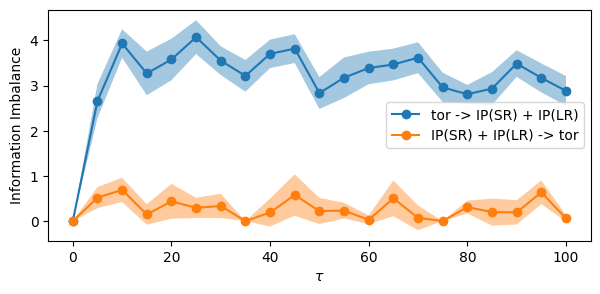

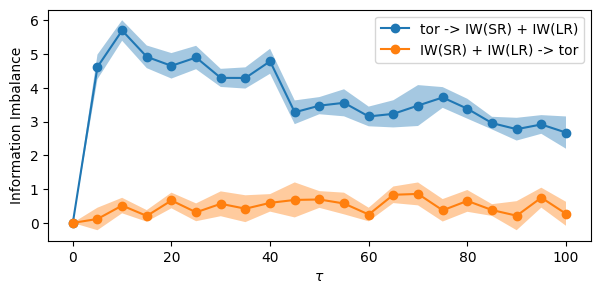

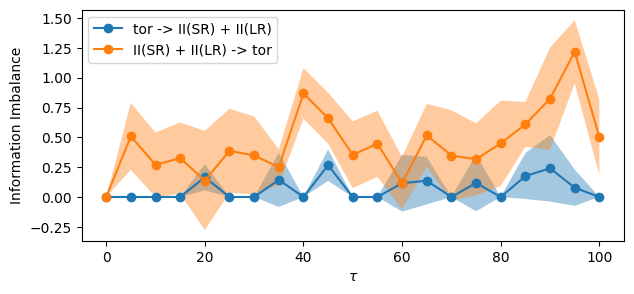

In [ ]:
for case in cases:
    plt.figure(figsize=(7,3))
    plt.plot(taus, IGs_XtoY[case], 'o-', label=f"tor -> {dict_targets[case]}")
    plt.fill_between(taus, IGs_XtoY[case] - errs_XtoY[case], IGs_XtoY[case] + errs_XtoY[case], alpha = 0.4)
    plt.plot(taus, IGs_YtoX[case], 'o-', label=f"{dict_targets[case]} -> tor")
    plt.fill_between(taus, IGs_YtoX[case] - errs_YtoX[case], IGs_YtoX[case] + errs_YtoX[case], alpha = 0.4)
    #plt.hlines(1.0, taus[0], taus[-1], linestyle="--", color="black")

    plt.legend()
    plt.ylabel("Imbalance Gain")
    plt.xlabel("$\\tau$")
    plt.show()